In [1]:
# Import
import tensorflow as tf
mnist = tf.keras.datasets.mnist
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# Train model

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)), # makes the multidimensional array to 1D vektor
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2), # turns off 20% of random neurons each step
    tf.keras.layers.Dense(10, activation="softmax") # output. 10 is because MNIST has 10 different answers 0-9. 
                                                    # Softmax converts the neurons rawdata to % "I am 88% it's a 2 etc"
    ])

model.compile(optimizer="adam", # adjusts the weights based on the error
              loss="sparse_categorical_crossentropy", # measures how wrong the model is
              metrics=["accuracy"] # shows you statistics (does not affect anything)
              )

history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)
model.evaluate(x_test, y_test)

c:\Users\Alexb\ws\ai-intro-vlad\grupp_project7\.venv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9046 - loss: 0.3302 - val_accuracy: 0.9553 - val_loss: 0.1575
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9534 - loss: 0.1588 - val_accuracy: 0.9647 - val_loss: 0.1210
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9651 - loss: 0.1161 - val_accuracy: 0.9711 - val_loss: 0.0996
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9708 - loss: 0.0946 - val_accuracy: 0.9725 - val_loss: 0.0930
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9758 - loss: 0.0786 - val_accuracy: 0.9731 - val_loss: 0.0862
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - accuracy: 0.9768 - loss: 0.0745


[0.0745251476764679, 0.9768000245094299]

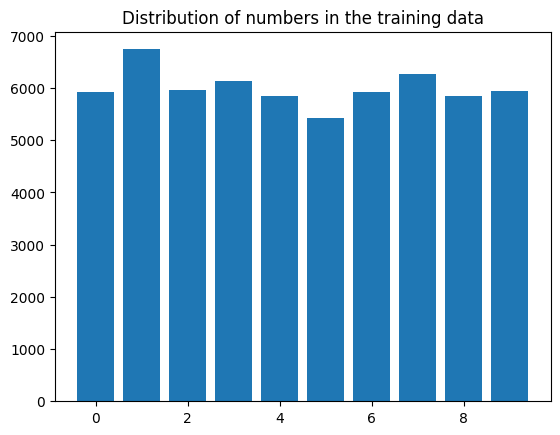

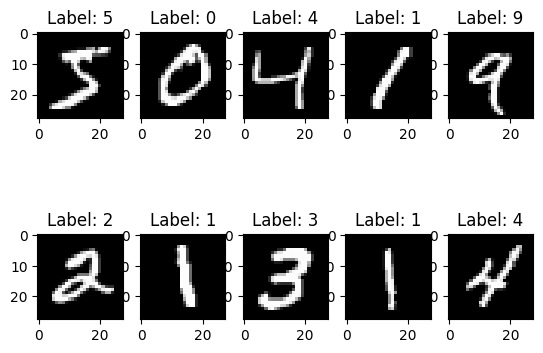

In [3]:
# Eda bars

# How many of each number exists?
# x_train = the pictures
# y_train = correct answers
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts)
plt.title("Distribution of numbers in the training data")
plt.show()

# Shows a few examples
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step


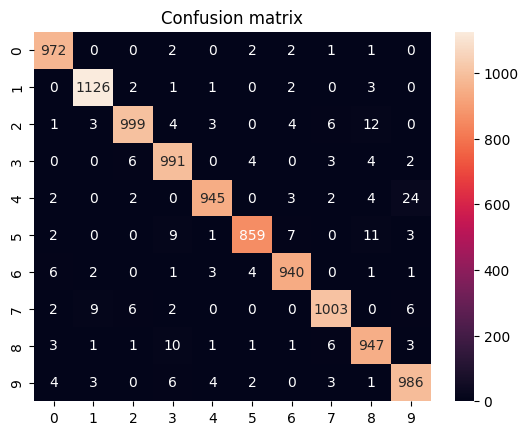

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.98      0.97      1010
           4       0.99      0.96      0.97       982
           5       0.99      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.96      0.97      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [4]:
y_pred = np.argmax(model.predict(x_test), axis=1)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.show()

print(classification_report(y_test, y_pred))

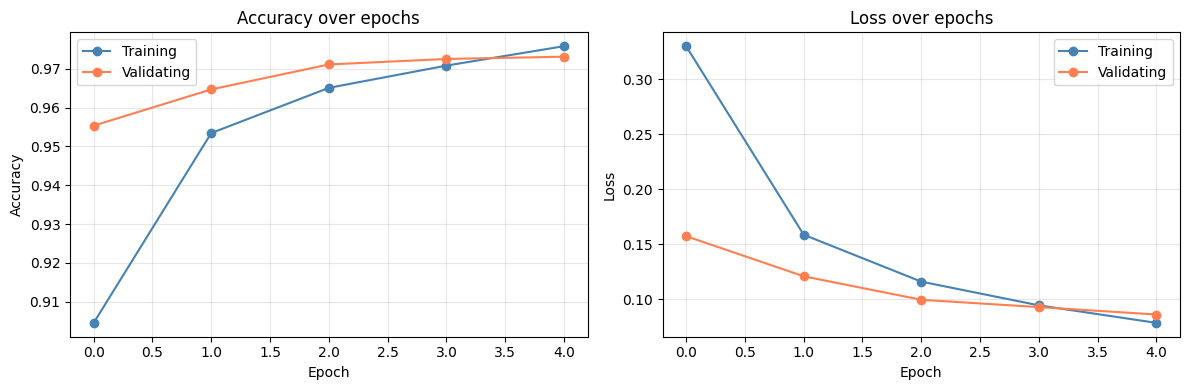

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'], label='Training', marker='o', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Validating', marker='o', color='coral')
ax1.set_title('Accuracy over epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Training', marker='o', color='steelblue')
ax2.plot(history.history['val_loss'], label='Validating', marker='o', color='coral')
ax2.set_title('Loss over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()